# 02. 금융 시계열 정상성 진단

## 분석 목적

본 노트북은 2010년 1월부터 2024년 12월까지의 KOSPI 및 거시·금융 변수에 대해 정상성(stationarity)을 진단하고, 후속 회귀분석에 적용할 변수 변환 방식을 결정한다.

금융 시계열은 장기 추세와 높은 지속성을 가지는 경우가 많다. 비정상 시계열을 수준 변수 그대로 회귀분석에 사용하면 실제 경제적 관계가 없음에도 높은 결정계수와 유의한 회귀계수가 나타나는 허위회귀(spurious regression)가 발생할 수 있다.

따라서 회귀모형을 적합하기 전에 다음 절차를 수행한다.

1. 수준 변수의 시계열 추이와 자기상관 구조를 탐색한다.
2. ADF 검정과 KPSS 검정을 함께 적용한다.
3. 두 검정의 귀무가설 차이를 고려하여 정상성을 종합 판단한다.
4. 수준 변수가 비정상으로 판단되면 1차 차분을 적용한다.
5. 차분 변수에 동일한 검정을 반복하여 정상성 확보 여부를 확인한다.
6. 검정 결과와 변환 결정 근거를 CSV로 저장한다.

## 사용 변수

| 변수              | 의미            |
| --------------- | ------------- |
| `KOSPI`         | 한국 종합주가지수     |
| `SP500`         | 미국 S&P 500 지수 |
| `Exchange_Rate` | 원/달러 환율       |
| `WTI_Oil`       | WTI 원유 선물 가격  |
| `Interest_Rate` | 국고채 3년 월평균 금리 |

## 검정 해석 원칙

### ADF 검정

* 귀무가설 (H_0): 단위근이 존재하며 비정상 시계열이다.
* 대립가설 (H_1): 단위근이 없으며 정상 시계열이다.
* 유의수준 5%에서 `p-value < 0.05`이면 비정상이라는 귀무가설을 기각한다.

### KPSS 검정

* 귀무가설 (H_0): 시계열은 정상이다.
* 대립가설 (H_1): 시계열은 비정상이다.
* 유의수준 5%에서 `p-value < 0.05`이면 정상이라는 귀무가설을 기각한다.

ADF와 KPSS는 귀무가설이 서로 반대이므로, 단일 검정 결과만으로 결론을 내리지 않고 두 결과를 함께 해석한다.


In [1]:
from __future__ import annotations

import sys
import warnings
from datetime import datetime
from pathlib import Path
from typing import Dict, List
from zoneinfo import ZoneInfo

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller, kpss

plt.rcParams["axes.unicode_minus"] = False


def find_project_root(start: Path | None = None) -> Path:
    """config.yaml이 위치한 프로젝트 최상위 경로를 탐색한다."""
    start = Path.cwd() if start is None else Path(start).resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "config.yaml").is_file():
            return candidate

    raise FileNotFoundError(
        "config.yaml을 찾지 못했습니다. "
        "노트북이 프로젝트 폴더 내부에 있는지 확인하세요."
    )


ROOT = find_project_root()

KST = ZoneInfo("Asia/Seoul")
RUN_TIMESTAMP = datetime.now(KST)

print(f"[INFO] Project root: {ROOT}")
print(f"[INFO] Run timestamp (KST): {RUN_TIMESTAMP:%Y-%m-%d %H:%M:%S}")
print(f"[INFO] Python version: {sys.version.split()[0]}")

[INFO] Project root: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI
[INFO] Run timestamp (KST): 2026-06-27 06:40:42
[INFO] Python version: 3.13.3


## 1. 설정 파일과 최종 분석 데이터 불러오기

정상성 검정에 앞서 프로젝트 설정과 최종 월별 분석 데이터를 불러온다.

이 단계에서는 데이터 기간, 변수명, 행·열 수, 중복 월, 결측치 및 수치형 변환 가능 여부를 다시 확인한다. 데이터 수집·정제 노트북의 결과를 그대로 신뢰하지 않고, 분석 노트북에서도 입력 데이터의 무결성을 독립적으로 검증한다.

In [2]:
def load_config(root: Path) -> Dict:
    """config.yaml을 읽고 필수 설정 항목을 확인한다."""
    config_path = root / "config.yaml"

    if not config_path.is_file():
        raise FileNotFoundError(
            f"설정 파일을 찾지 못했습니다: {config_path}"
        )

    with open(config_path, "r", encoding="utf-8") as file:
        config = yaml.safe_load(file)

    if not isinstance(config, dict):
        raise ValueError(
            "config.yaml의 최상위 구조가 올바르지 않습니다."
        )

    required_sections = [
        "data",
        "period",
        "yfinance_tickers",
    ]

    missing_sections = [
        section
        for section in required_sections
        if section not in config
    ]

    if missing_sections:
        raise KeyError(
            f"config.yaml에 필수 섹션이 없습니다: "
            f"{missing_sections}"
        )

    return config


cfg = load_config(ROOT)

processed_dir = (
    ROOT / cfg["data"]["processed_dir"]
)

fig_dir = ROOT / "outputs" / "figures"
metric_dir = ROOT / "outputs" / "metrics"
report_dir = ROOT / "outputs" / "reports"

final_dataset_path = (
    processed_dir
    / cfg["data"]["final_dataset_file"]
)

for directory in [
    processed_dir,
    fig_dir,
    metric_dir,
    report_dir,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print(f"[INFO] Dataset path: {final_dataset_path}")
print(
    f"[INFO] Analysis period: "
    f"{cfg['period']['start']} ~ "
    f"{cfg['period']['end']}"
)

[INFO] Dataset path: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\data\processed\kospi_macro_monthly.csv
[INFO] Analysis period: 2010-01-01 ~ 2024-12-31


In [3]:
def load_and_validate_analysis_data(
    path: Path,
    expected_columns: List[str],
    expected_start: str,
    expected_end: str,
) -> pd.DataFrame:
    """최종 분석 데이터를 불러오고 구조와 품질을 검증한다."""
    if not path.is_file():
        raise FileNotFoundError(
            f"최종 분석 데이터를 찾지 못했습니다: {path}"
        )

    data = pd.read_csv(path)

    if "Date" not in data.columns:
        raise KeyError(
            "분석 데이터에 Date 열이 없습니다."
        )

    data["Date"] = pd.to_datetime(
        data["Date"],
        errors="raise",
    )

    data = (
        data
        .set_index("Date")
        .sort_index()
    )

    data.index.name = "Date"

    data = data.apply(
        pd.to_numeric,
        errors="coerce",
    )

    expected_index = pd.period_range(
        start=pd.Timestamp(
            expected_start
        ).to_period("M"),
        end=pd.Timestamp(
            expected_end
        ).to_period("M"),
        freq="M",
    ).to_timestamp()

    missing_months = expected_index.difference(
        data.index
    )

    unexpected_months = data.index.difference(
        expected_index
    )

    duplicated_dates = int(
        data.index.duplicated().sum()
    )

    missing_values = int(
        data.isna().sum().sum()
    )

    infinite_values = int(
        np.isinf(
            data.to_numpy(dtype=float)
        ).sum()
    )

    print("[ANALYSIS DATA STRUCTURE]")
    print(f"Shape: {data.shape}")
    print(f"Columns: {data.columns.tolist()}")
    print(
        f"Period: "
        f"{data.index.min():%Y-%m} ~ "
        f"{data.index.max():%Y-%m}"
    )
    print(f"Index sorted: {data.index.is_monotonic_increasing}")
    print(f"Duplicated dates: {duplicated_dates}")
    print(
        f"Missing months: "
        f"{missing_months.strftime('%Y-%m').tolist()}"
    )
    print(
        f"Unexpected months: "
        f"{unexpected_months.strftime('%Y-%m').tolist()}"
    )
    print(f"Missing values: {missing_values}")
    print(f"Infinite values: {infinite_values}")

    print("\n[VARIABLE SUMMARY]")
    display(
        data.describe().T[
            ["count", "mean", "std", "min", "max"]
        ]
    )

    if data.columns.tolist() != expected_columns:
        raise ValueError(
            "변수명 또는 변수 순서가 예상과 다릅니다.\n"
            f"현재: {data.columns.tolist()}\n"
            f"예상: {expected_columns}"
        )

    if len(missing_months) > 0:
        raise ValueError(
            f"누락된 월이 존재합니다: "
            f"{missing_months.strftime('%Y-%m').tolist()}"
        )

    if len(unexpected_months) > 0:
        raise ValueError(
            f"분석 기간 밖의 월이 존재합니다: "
            f"{unexpected_months.strftime('%Y-%m').tolist()}"
        )

    if duplicated_dates > 0:
        raise ValueError(
            "중복된 월 인덱스가 존재합니다."
        )

    if missing_values > 0:
        raise ValueError(
            "분석 데이터에 결측치가 존재합니다."
        )

    if infinite_values > 0:
        raise ValueError(
            "분석 데이터에 무한대 값이 존재합니다."
        )

    if data.shape != (
        len(expected_index),
        len(expected_columns),
    ):
        raise ValueError(
            "분석 데이터 크기가 예상과 다릅니다."
        )

    print(
        "\n[PASS] 정상성 진단 입력 데이터의 "
        "무결성 검증을 통과했습니다."
    )

    return data


expected_columns = [
    *cfg["yfinance_tickers"].keys(),
    "Interest_Rate",
]

df_level = load_and_validate_analysis_data(
    path=final_dataset_path,
    expected_columns=expected_columns,
    expected_start=cfg["period"]["start"],
    expected_end=cfg["period"]["end"],
)

display(df_level.head())
display(df_level.tail())

[ANALYSIS DATA STRUCTURE]
Shape: (180, 5)
Columns: ['KOSPI', 'SP500', 'Exchange_Rate', 'WTI_Oil', 'Interest_Rate']
Period: 2010-01 ~ 2024-12
Index sorted: True
Duplicated dates: 0
Missing months: []
Unexpected months: []
Missing values: 0
Infinite values: 0

[VARIABLE SUMMARY]


,count,mean,std,min,max
KOSPI,180.0,2223.328780,356.821403,1594.579956,3296.679932
SP500,180.0,2736.680164,1273.219463,1030.709961,6032.379883
Exchange_Rate,180.0,1166.897276,93.591807,1013.299988,1467.390015
WTI_Oil,180.0,72.057111,21.266197,18.840000,114.669998
Interest_Rate,180.0,2.451939,0.935896,0.826000,4.290000



[PASS] 정상성 진단 입력 데이터의 무결성 검증을 통과했습니다.


,KOSPI,SP500,Exchange_Rate,WTI_Oil,Interest_Rate
Date,,,,,
2010-01-01,1602.430054,1073.869995,1158.199951,72.889999,4.29
2010-02-01,1594.579956,1104.489990,1161.400024,79.660004,4.19
2010-03-01,1692.849976,1169.430054,1131.599976,83.760002,3.94
2010-04-01,1741.560059,1186.689941,1107.900024,86.150002,3.77
2010-05-01,1641.250000,1089.410034,1200.000000,73.970001,3.70


,KOSPI,SP500,Exchange_Rate,WTI_Oil,Interest_Rate
Date,,,,,
2024-08-01,2674.310059,5648.399902,1332.880005,73.550003,2.924
2024-09-01,2593.270020,5762.479980,1309.300049,68.169998,2.868
2024-10-01,2556.149902,5705.450195,1378.569946,69.260002,2.911
2024-11-01,2455.909912,6032.379883,1393.300049,68.000000,2.858
2024-12-01,2399.489990,5881.629883,1467.390015,71.720001,2.590


## 2. 수준 변수의 시계열 추이

ADF·KPSS 검정을 수행하기 전에 각 수준 변수의 장기 추세와 변동 구조를 시각적으로 확인한다.

월별 원자료와 12개월 이동평균을 함께 표시하여 장기적인 상승·하락 추세, 변동성 변화 및 구조적 변화 가능성을 탐색한다.

시각적 추세는 정상성 여부에 대한 참고 자료일 뿐이며, 최종 판단은 이후 ADF 및 KPSS 검정 결과를 함께 사용한다.

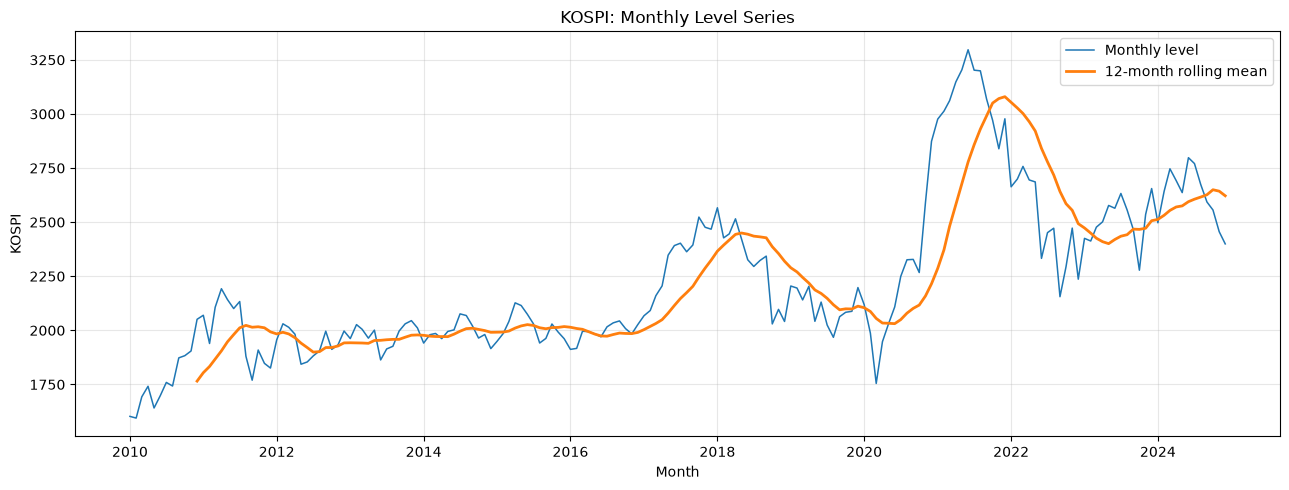

[SAVED] KOSPI: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\figures\stationarity_level_kospi.png


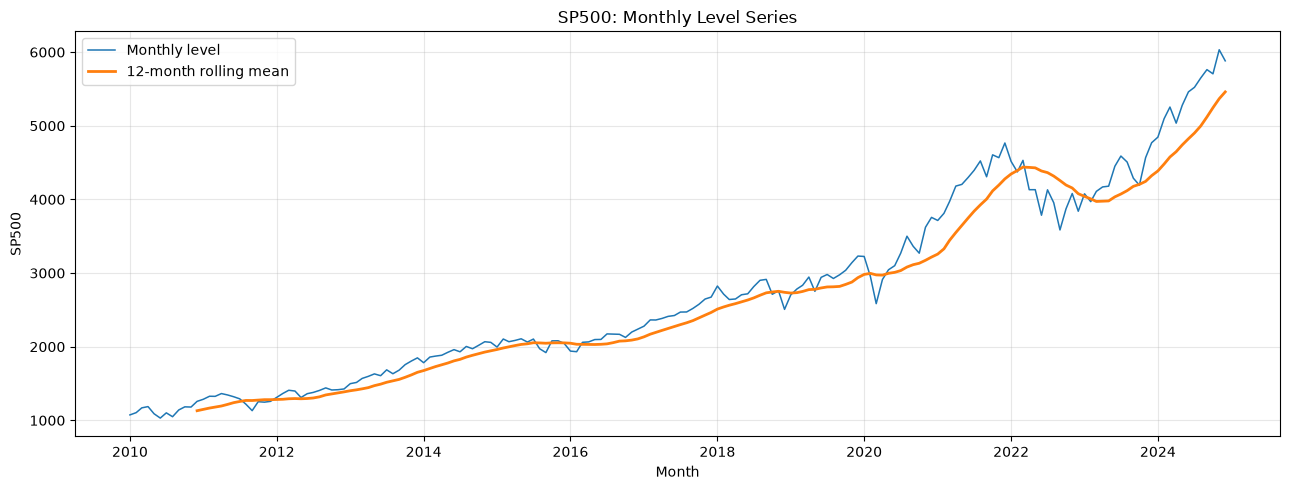

[SAVED] SP500: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\figures\stationarity_level_sp500.png


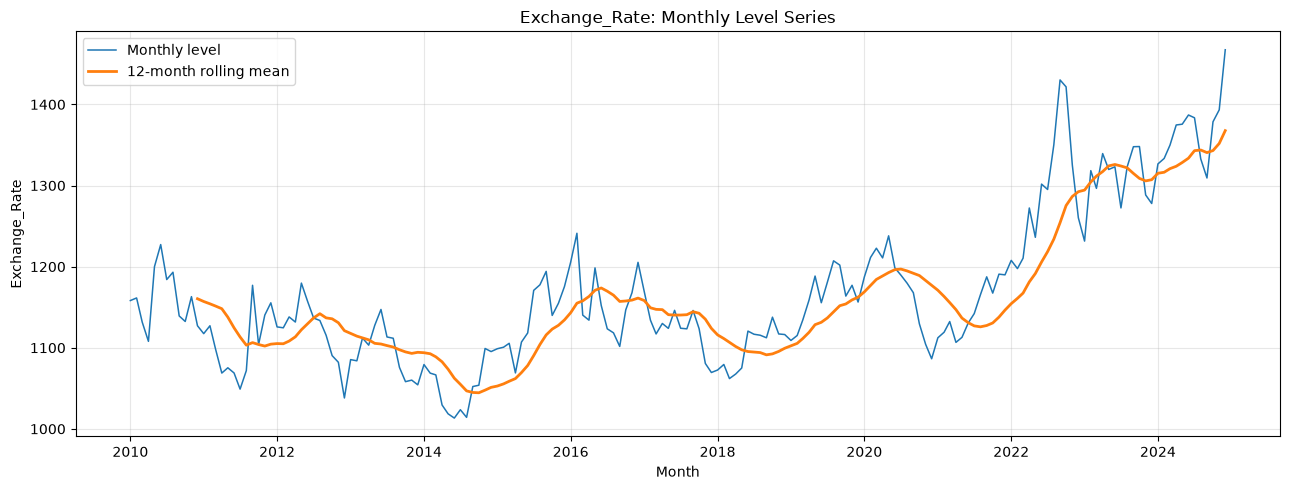

[SAVED] Exchange_Rate: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\figures\stationarity_level_exchange_rate.png


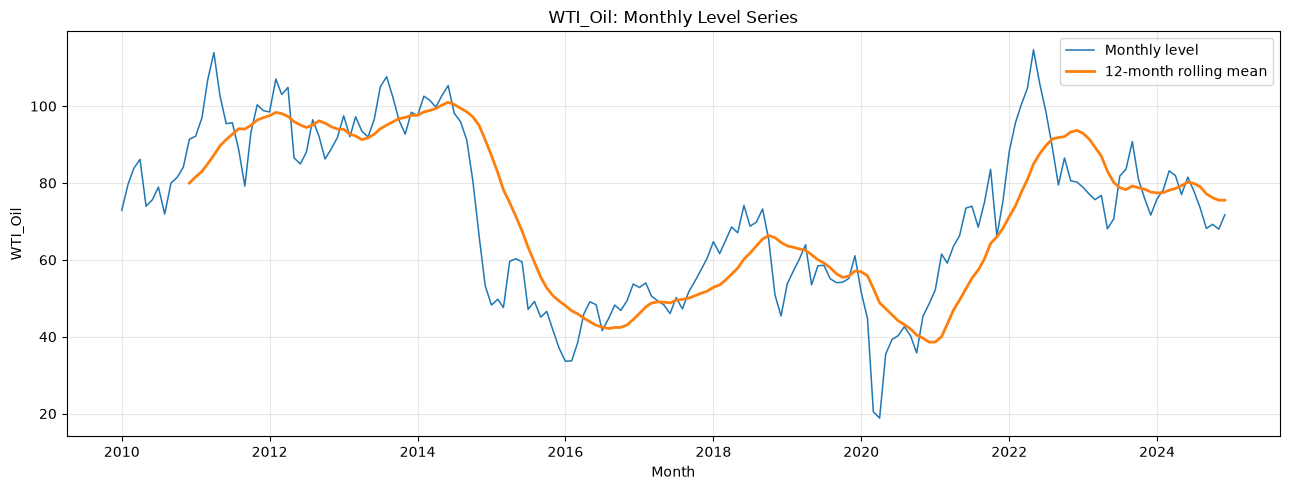

[SAVED] WTI_Oil: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\figures\stationarity_level_wti_oil.png


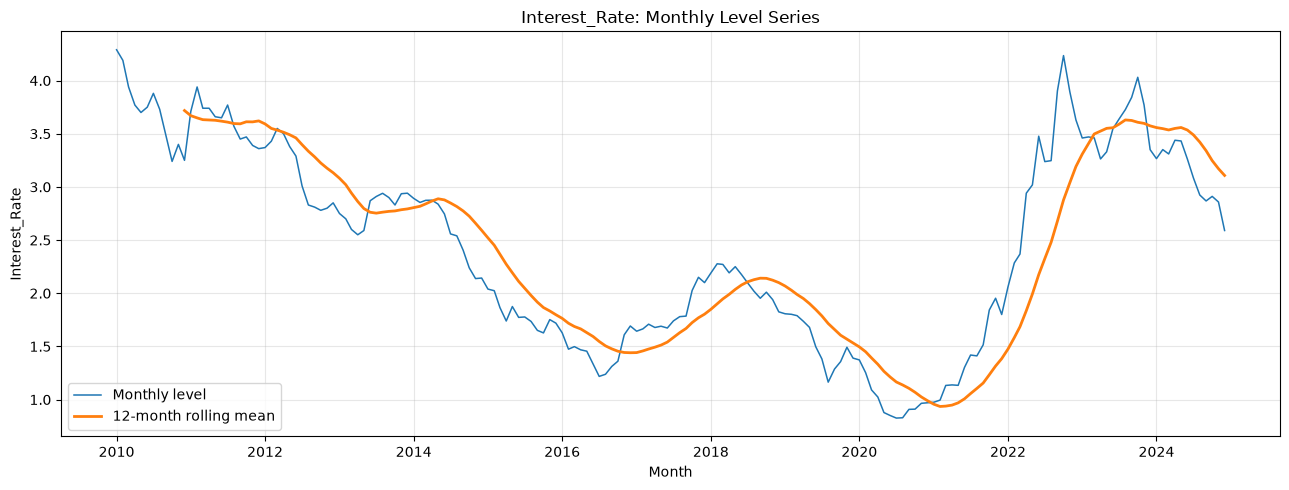

[SAVED] Interest_Rate: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\figures\stationarity_level_interest_rate.png


In [4]:
level_figure_paths = {}

for variable in df_level.columns:
    series = df_level[variable]
    rolling_mean_12 = series.rolling(
        window=12,
        min_periods=12,
    ).mean()

    figure_path = (
        fig_dir
        / f"stationarity_level_{variable.lower()}.png"
    )

    fig, ax = plt.subplots(figsize=(13, 5))

    ax.plot(
        series.index,
        series.values,
        linewidth=1.1,
        label="Monthly level",
    )

    ax.plot(
        rolling_mean_12.index,
        rolling_mean_12.values,
        linewidth=2.0,
        label="12-month rolling mean",
    )

    ax.set_title(
        f"{variable}: Monthly Level Series"
    )

    ax.set_xlabel("Month")
    ax.set_ylabel(variable)

    ax.grid(
        True,
        alpha=0.3,
    )

    ax.legend(
        loc="best",
    )

    fig.tight_layout()

    fig.savefig(
        figure_path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    level_figure_paths[variable] = figure_path

    print(
        f"[SAVED] {variable}: {figure_path}"
    )

## 3. 수준 변수의 자기상관 구조

수준 시계열의 지속성과 자기상관 구조를 확인하기 위해 ACF를 계산한다.

정상 시계열은 일반적으로 자기상관이 비교적 빠르게 감소하지만, 단위근을 포함한 비정상 시계열은 여러 시차에 걸쳐 높은 자기상관이 유지되며 천천히 감소하는 경향이 있다.

다만 ACF 형태만으로 정상성을 확정하지 않고, 이후 ADF 및 KPSS 검정 결과와 함께 해석한다.

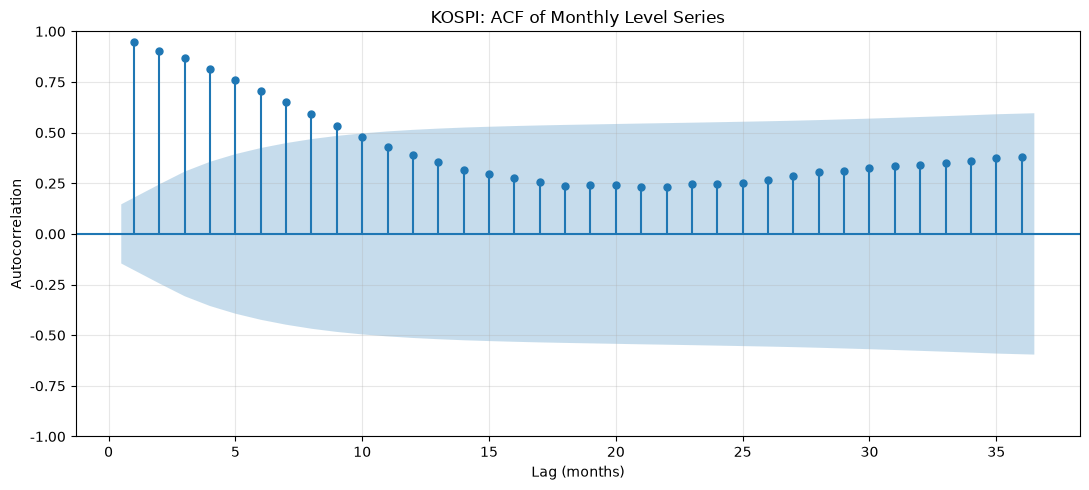

[SAVED] KOSPI: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\figures\stationarity_acf_level_kospi.png


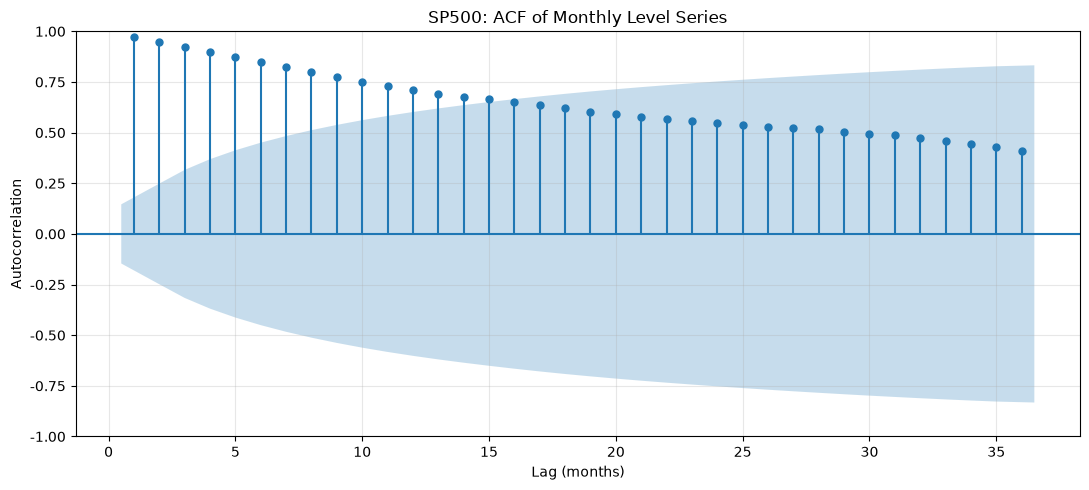

[SAVED] SP500: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\figures\stationarity_acf_level_sp500.png


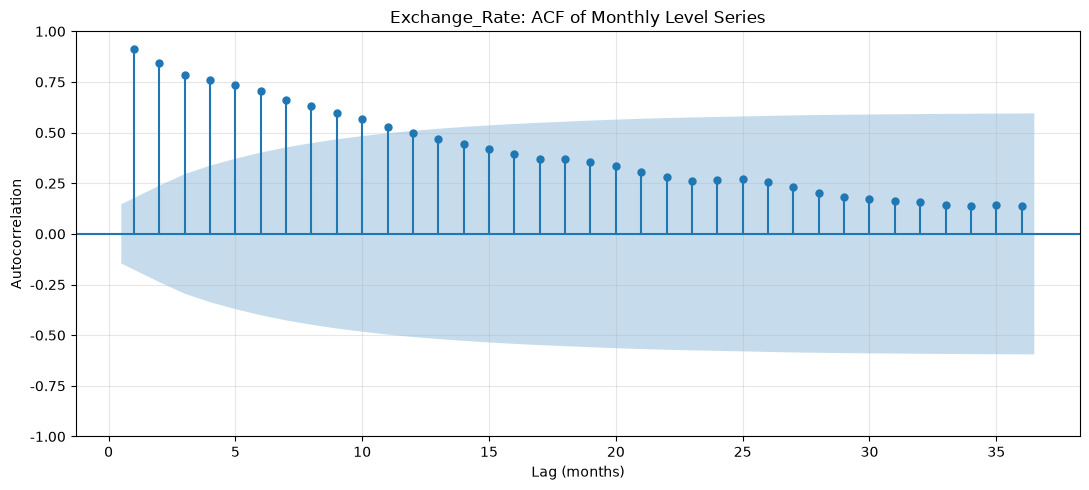

[SAVED] Exchange_Rate: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\figures\stationarity_acf_level_exchange_rate.png


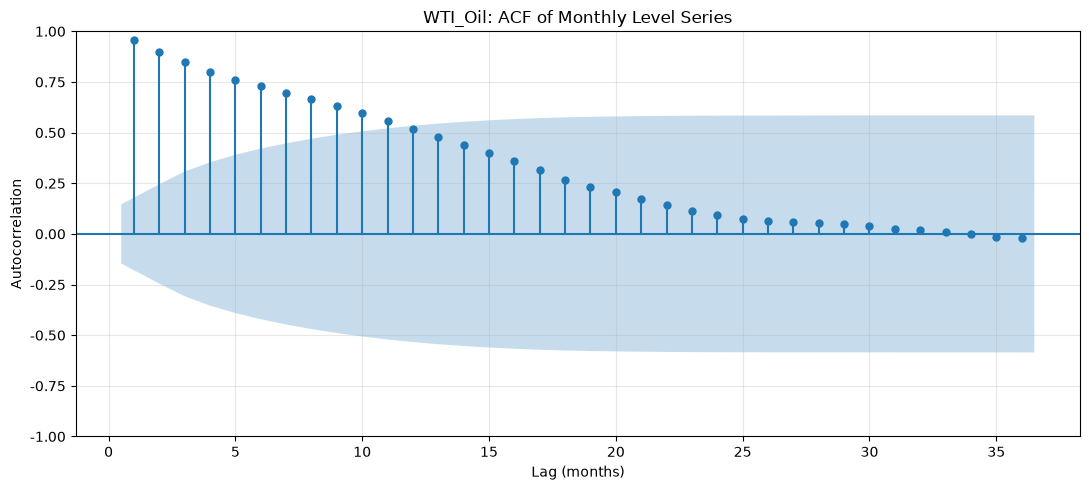

[SAVED] WTI_Oil: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\figures\stationarity_acf_level_wti_oil.png


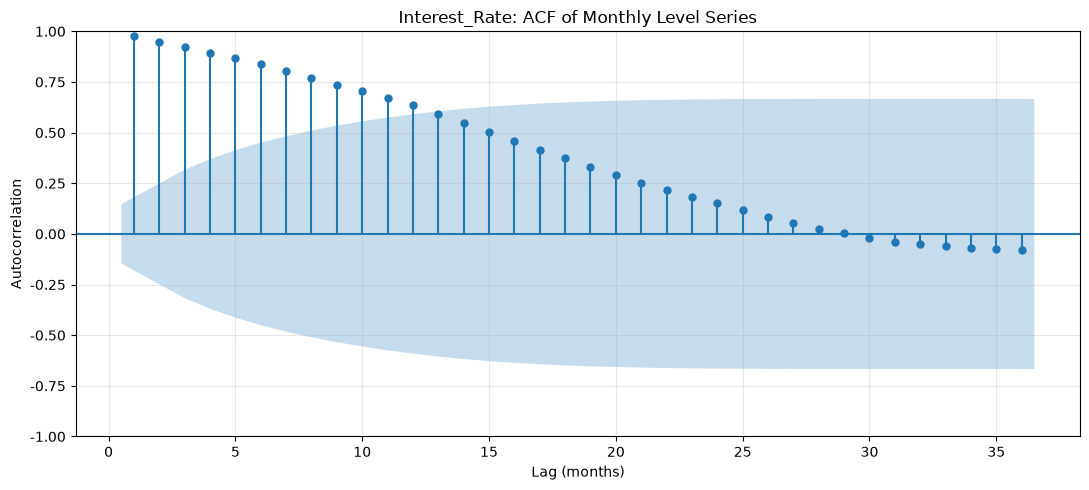

[SAVED] Interest_Rate: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\figures\stationarity_acf_level_interest_rate.png


In [5]:
acf_level_figure_paths = {}

acf_lags = 36

for variable in df_level.columns:
    figure_path = (
        fig_dir
        / f"stationarity_acf_level_{variable.lower()}.png"
    )

    fig, ax = plt.subplots(figsize=(11, 5))

    plot_acf(
        df_level[variable],
        lags=acf_lags,
        alpha=0.05,
        zero=False,
        ax=ax,
    )

    ax.set_title(
        f"{variable}: ACF of Monthly Level Series"
    )

    ax.set_xlabel("Lag (months)")
    ax.set_ylabel("Autocorrelation")

    ax.grid(
        True,
        alpha=0.3,
    )

    fig.tight_layout()

    fig.savefig(
        figure_path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    acf_level_figure_paths[variable] = figure_path

    print(
        f"[SAVED] {variable}: {figure_path}"
    )

## 4. 수준 변수의 ADF·KPSS 정상성 검정

수준 시계열의 정상성을 정량적으로 판단하기 위해 ADF 검정과 KPSS 검정을 함께 수행한다.

- ADF 검정의 귀무가설은 단위근이 존재하는 비정상 시계열이다.
- KPSS 검정의 귀무가설은 수준 정상 시계열이다.
- 유의수준은 5%로 설정한다.
- ADF의 시차는 AIC 기준으로 자동 선택한다.
- KPSS의 시차는 `auto` 방식으로 결정한다.

두 검정의 귀무가설이 서로 반대이므로 결과를 다음과 같이 종합 판단한다.

| ADF 결과 | KPSS 결과 | 종합 판단 |
|---|---|---|
| 귀무가설 기각 | 귀무가설 기각 안 함 | 정상 |
| 귀무가설 기각 안 함 | 귀무가설 기각 | 비정상 |
| 귀무가설 기각 | 귀무가설 기각 | 상충 |
| 귀무가설 기각 안 함 | 귀무가설 기각 안 함 | 불확정 |

상충 또는 불확정 결과는 추세, 구조 변화, 검정력 부족 등의 가능성을 추가로 고려해야 한다.

In [6]:
SIGNIFICANCE_LEVEL = float(
    cfg.get("diagnostics", {}).get(
        "significance_level",
        cfg.get("diagnostics", {}).get(
            "alpha",
            0.05,
        ),
    )
)


def interpret_stationarity_tests(
    adf_pvalue: float,
    kpss_pvalue: float,
    alpha: float = 0.05,
) -> str:
    """ADF와 KPSS 결과를 결합하여 정상성을 분류한다."""
    adf_reject = adf_pvalue < alpha
    kpss_reject = kpss_pvalue < alpha

    if adf_reject and not kpss_reject:
        return "Stationary"

    if not adf_reject and kpss_reject:
        return "Non-stationary"

    if adf_reject and kpss_reject:
        return "Conflicting"

    return "Inconclusive"


def run_stationarity_tests(
    series: pd.Series,
    variable: str,
    transformation: str,
    alpha: float = 0.05,
) -> Dict:
    """단일 시계열에 ADF와 KPSS 검정을 수행한다."""
    clean_series = (
        series
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .astype(float)
    )

    if clean_series.empty:
        raise ValueError(
            f"{variable}의 유효한 관측값이 없습니다."
        )

    if clean_series.nunique() <= 1:
        raise ValueError(
            f"{variable}은 상수 시계열이므로 검정을 수행할 수 없습니다."
        )

    adf_result = adfuller(
        clean_series,
        regression="c",
        autolag="AIC",
    )

    kpss_warning_messages = []

    with warnings.catch_warnings(record=True) as caught_warnings:
        warnings.simplefilter("always")

        kpss_result = kpss(
            clean_series,
            regression="c",
            nlags="auto",
        )

        kpss_warning_messages = [
            str(item.message)
            for item in caught_warnings
        ]

    adf_statistic = float(adf_result[0])
    adf_pvalue = float(adf_result[1])
    adf_used_lag = int(adf_result[2])
    adf_nobs = int(adf_result[3])
    adf_critical_values = adf_result[4]

    kpss_statistic = float(kpss_result[0])
    kpss_pvalue = float(kpss_result[1])
    kpss_used_lag = int(kpss_result[2])
    kpss_critical_values = kpss_result[3]

    decision = interpret_stationarity_tests(
        adf_pvalue=adf_pvalue,
        kpss_pvalue=kpss_pvalue,
        alpha=alpha,
    )

    return {
        "variable": variable,
        "transformation": transformation,
        "n_observations": len(clean_series),
        "significance_level": alpha,
        "adf_statistic": adf_statistic,
        "adf_pvalue": adf_pvalue,
        "adf_used_lag": adf_used_lag,
        "adf_nobs": adf_nobs,
        "adf_critical_1pct": float(
            adf_critical_values["1%"]
        ),
        "adf_critical_5pct": float(
            adf_critical_values["5%"]
        ),
        "adf_critical_10pct": float(
            adf_critical_values["10%"]
        ),
        "adf_reject_unit_root": (
            adf_pvalue < alpha
        ),
        "kpss_statistic": kpss_statistic,
        "kpss_pvalue": kpss_pvalue,
        "kpss_used_lag": kpss_used_lag,
        "kpss_critical_1pct": float(
            kpss_critical_values["1%"]
        ),
        "kpss_critical_5pct": float(
            kpss_critical_values["5%"]
        ),
        "kpss_critical_10pct": float(
            kpss_critical_values["10%"]
        ),
        "kpss_reject_stationarity": (
            kpss_pvalue < alpha
        ),
        "combined_decision": decision,
        "kpss_warning": " | ".join(
            kpss_warning_messages
        ),
    }


print(
    f"[INFO] Significance level: "
    f"{SIGNIFICANCE_LEVEL:.2%}"
)

[INFO] Significance level: 5.00%


In [7]:
level_test_records = []

for variable in df_level.columns:
    result = run_stationarity_tests(
        series=df_level[variable],
        variable=variable,
        transformation="Level",
        alpha=SIGNIFICANCE_LEVEL,
    )

    level_test_records.append(result)


level_stationarity_results = (
    pd.DataFrame(level_test_records)
    .set_index("variable")
)

level_stationarity_path = (
    metric_dir / "stationarity_level_tests.csv"
)

level_stationarity_results.to_csv(
    level_stationarity_path,
    index=True,
    index_label="variable",
    encoding="utf-8-sig",
)


display_columns = [
    "n_observations",
    "adf_statistic",
    "adf_pvalue",
    "adf_used_lag",
    "adf_reject_unit_root",
    "kpss_statistic",
    "kpss_pvalue",
    "kpss_used_lag",
    "kpss_reject_stationarity",
    "combined_decision",
]

print("[LEVEL STATIONARITY TEST RESULTS]")

display(
    level_stationarity_results[
        display_columns
    ].round(6)
)

print(
    f"\n[SAVED] Level stationarity tests: "
    f"{level_stationarity_path}"
)

[LEVEL STATIONARITY TEST RESULTS]


,n_observations,adf_statistic,adf_pvalue,adf_used_lag,adf_reject_unit_root,kpss_statistic,kpss_pvalue,kpss_used_lag,kpss_reject_stationarity,combined_decision
variable,,,,,,,,,,
KOSPI,180,-2.268390,0.182365,3,False,1.274143,0.010000,9,True,Non-stationary
SP500,180,1.684903,0.998091,2,False,1.810149,0.010000,9,True,Non-stationary
Exchange_Rate,180,-1.253305,0.650256,0,False,1.253205,0.010000,8,True,Non-stationary
WTI_Oil,180,-2.330634,0.162278,1,False,0.447373,0.056736,9,False,Inconclusive
Interest_Rate,180,-2.829722,0.054152,12,False,0.467772,0.048925,9,True,Non-stationary



[SAVED] Level stationarity tests: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\metrics\stationarity_level_tests.csv


## 5. 1차 차분 데이터 생성

수준 변수 검정 결과 KOSPI, S&P 500, 원/달러 환율은 명확한 비정상 시계열로 판단되었다.

WTI는 ADF와 KPSS가 모두 귀무가설을 기각하지 못해 불확정으로 분류되었고, 국고채 3년 금리는 두 검정 모두 5% 유의수준 경계에 위치하였다.

이에 모든 변수를 1차 차분하여 월간 절대 변화량으로 변환한 뒤, 동일한 ADF·KPSS 검정을 다시 수행한다. 차분 후 정상성이 확보되는 경우 후속 단기 변화 회귀모형의 입력값으로 사용한다.

1차 차분은 다음과 같이 정의한다.

\[
\Delta X_t = X_t - X_{t-1}
\]

첫 관측치는 이전 시점이 없으므로 제거되며, 표본 수는 180개에서 179개로 감소한다.

In [8]:
df_diff = (
    df_level
    .diff(periods=1)
    .dropna()
)

df_diff.index.name = "Date"

expected_diff_shape = (
    len(df_level) - 1,
    df_level.shape[1],
)

diff_missing_values = int(
    df_diff.isna().sum().sum()
)

diff_infinite_values = int(
    np.isinf(
        df_diff.to_numpy(dtype=float)
    ).sum()
)

print("[FIRST-DIFFERENCE DATA STRUCTURE]")
print(f"Shape: {df_diff.shape}")
print(f"Expected shape: {expected_diff_shape}")
print(f"Columns: {df_diff.columns.tolist()}")
print(
    f"Period: "
    f"{df_diff.index.min():%Y-%m} ~ "
    f"{df_diff.index.max():%Y-%m}"
)
print(
    f"Index sorted: "
    f"{df_diff.index.is_monotonic_increasing}"
)
print(
    f"Duplicated dates: "
    f"{int(df_diff.index.duplicated().sum())}"
)
print(f"Missing values: {diff_missing_values}")
print(f"Infinite values: {diff_infinite_values}")

if df_diff.shape != expected_diff_shape:
    raise ValueError(
        "1차 차분 데이터의 크기가 예상과 다릅니다."
    )

if df_diff.columns.tolist() != df_level.columns.tolist():
    raise ValueError(
        "1차 차분 과정에서 변수명이 변경되었습니다."
    )

if not df_diff.index.is_monotonic_increasing:
    raise ValueError(
        "1차 차분 데이터의 인덱스가 정렬되어 있지 않습니다."
    )

if df_diff.index.duplicated().any():
    raise ValueError(
        "1차 차분 데이터에 중복 월이 존재합니다."
    )

if diff_missing_values > 0:
    raise ValueError(
        "1차 차분 데이터에 결측치가 존재합니다."
    )

if diff_infinite_values > 0:
    raise ValueError(
        "1차 차분 데이터에 무한대 값이 존재합니다."
    )

print(
    "\n[PASS] 1차 차분 데이터 생성 및 "
    "무결성 검증을 통과했습니다."
)

display(df_diff.head())

display(
    df_diff.describe().T[
        ["count", "mean", "std", "min", "max"]
    ]
)

[FIRST-DIFFERENCE DATA STRUCTURE]
Shape: (179, 5)
Expected shape: (179, 5)
Columns: ['KOSPI', 'SP500', 'Exchange_Rate', 'WTI_Oil', 'Interest_Rate']
Period: 2010-02 ~ 2024-12
Index sorted: True
Duplicated dates: 0
Missing values: 0
Infinite values: 0

[PASS] 1차 차분 데이터 생성 및 무결성 검증을 통과했습니다.


,KOSPI,SP500,Exchange_Rate,WTI_Oil,Interest_Rate
Date,,,,,
2010-02-01,-7.850098,30.619995,3.200073,6.770004,-0.10
2010-03-01,98.270020,64.940063,-29.800049,4.099998,-0.25
2010-04-01,48.710083,17.259888,-23.699951,2.389999,-0.17
2010-05-01,-100.310059,-97.279907,92.099976,-12.180000,-0.07
2010-06-01,57.040039,-58.700073,27.199951,1.659996,0.05


,count,mean,std,min,max
KOSPI,179.0,4.452849,103.726083,-353.260010,324.190186
SP500,179.0,26.858994,130.996315,-398.479980,374.000000
Exchange_Rate,179.0,1.727319,32.682657,-100.900024,105.199951
WTI_Oil,179.0,-0.006536,6.398898,-24.279999,16.650002
Interest_Rate,179.0,-0.009497,0.149939,-0.421000,0.656000


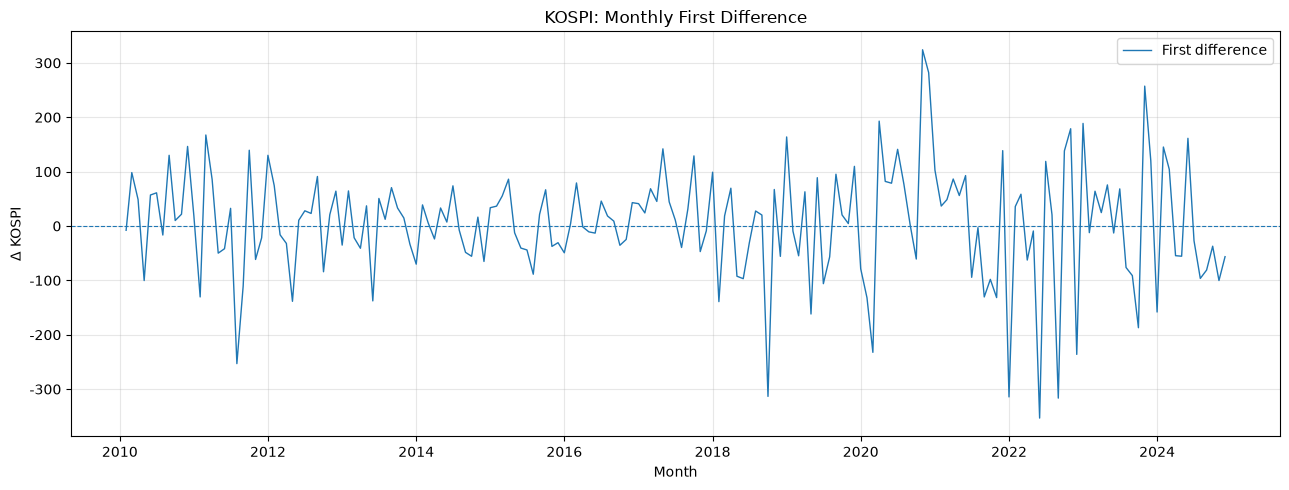

[SAVED] KOSPI: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\figures\stationarity_first_difference_kospi.png


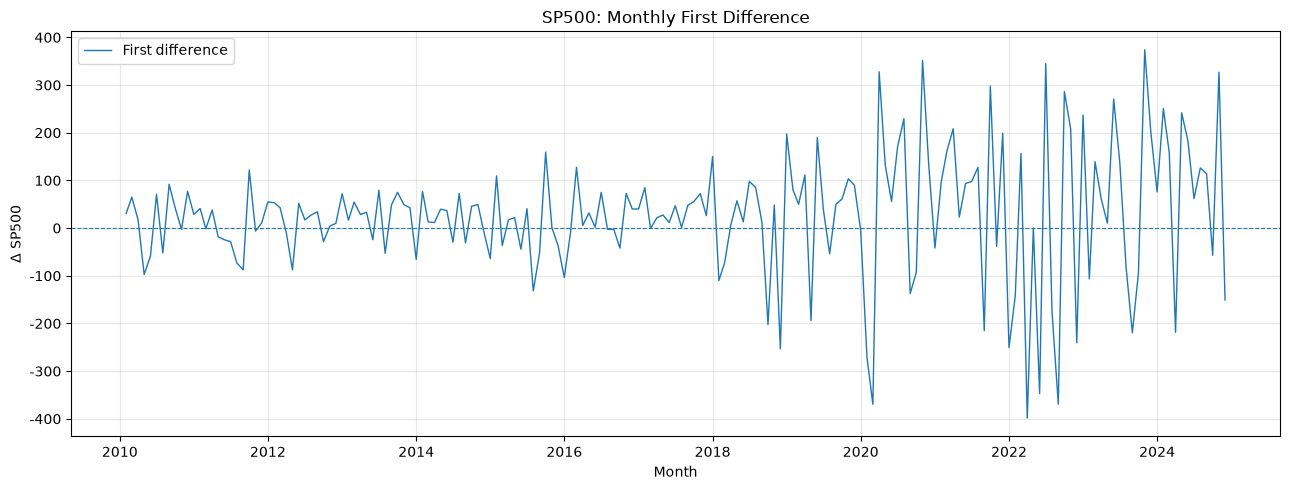

[SAVED] SP500: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\figures\stationarity_first_difference_sp500.png


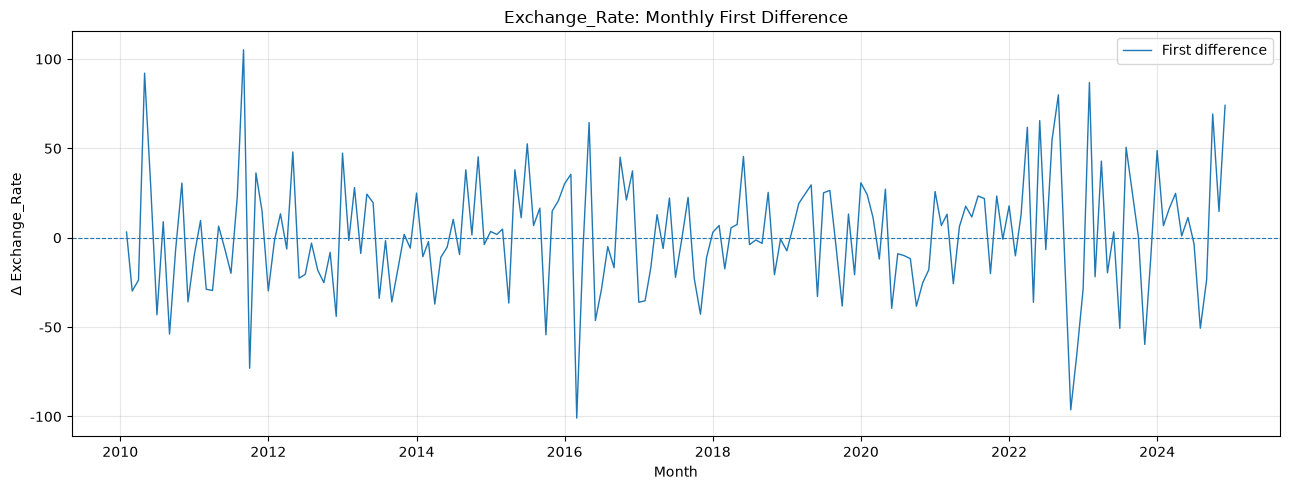

[SAVED] Exchange_Rate: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\figures\stationarity_first_difference_exchange_rate.png


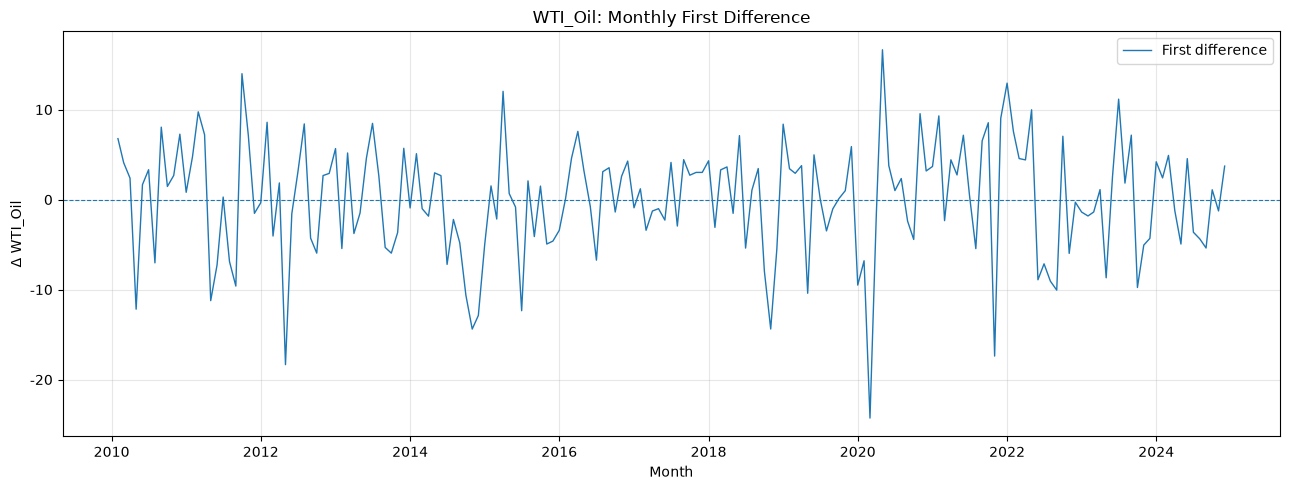

[SAVED] WTI_Oil: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\figures\stationarity_first_difference_wti_oil.png


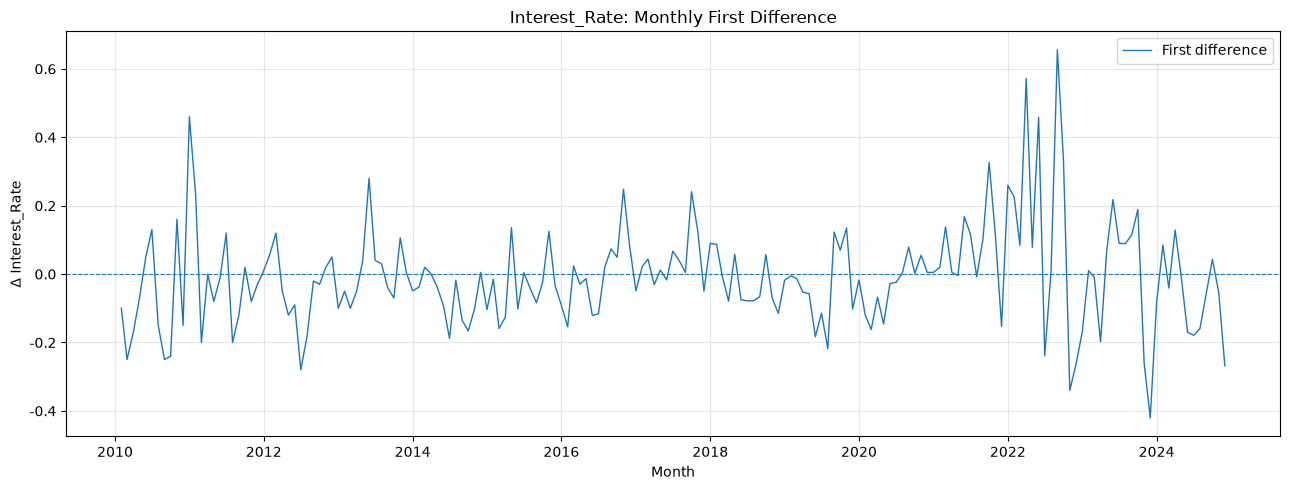

[SAVED] Interest_Rate: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\figures\stationarity_first_difference_interest_rate.png


In [9]:
diff_figure_paths = {}

for variable in df_diff.columns:
    figure_path = (
        fig_dir
        / f"stationarity_first_difference_{variable.lower()}.png"
    )

    fig, ax = plt.subplots(figsize=(13, 5))

    ax.plot(
        df_diff.index,
        df_diff[variable],
        linewidth=1.0,
        label="First difference",
    )

    ax.axhline(
        y=0,
        linewidth=0.8,
        linestyle="--",
    )

    ax.set_title(
        f"{variable}: Monthly First Difference"
    )

    ax.set_xlabel("Month")
    ax.set_ylabel(
        f"Δ {variable}"
    )

    ax.grid(
        True,
        alpha=0.3,
    )

    ax.legend(
        loc="best",
    )

    fig.tight_layout()

    fig.savefig(
        figure_path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    diff_figure_paths[variable] = figure_path

    print(
        f"[SAVED] {variable}: {figure_path}"
    )

## 6. 1차 차분 변수의 ADF·KPSS 정상성 검정

수준 변수에 적용한 것과 동일한 조건으로 1차 차분 시계열의 정상성을 재검정한다.

- ADF 검정: 상수항 포함, AIC 기준 시차 자동 선택
- KPSS 검정: 수준 정상성 검정, 시차 자동 선택
- 유의수준: 5%

차분 변수에서 ADF 귀무가설이 기각되고 KPSS 귀무가설이 기각되지 않으면 정상성이 확보된 것으로 판단한다.

모든 변수의 1차 차분이 정상으로 판정되면, 후속 회귀분석에서는 수준값 간 관계와 별도로 월간 변화량 간 단기 관계를 추정한다.

In [10]:
diff_test_records = []

for variable in df_diff.columns:
    result = run_stationarity_tests(
        series=df_diff[variable],
        variable=variable,
        transformation="First Difference",
        alpha=SIGNIFICANCE_LEVEL,
    )

    diff_test_records.append(result)


diff_stationarity_results = (
    pd.DataFrame(diff_test_records)
    .set_index("variable")
)

diff_stationarity_path = (
    metric_dir
    / "stationarity_first_difference_tests.csv"
)

diff_stationarity_results.to_csv(
    diff_stationarity_path,
    index=True,
    index_label="variable",
    encoding="utf-8-sig",
)


display_columns = [
    "n_observations",
    "adf_statistic",
    "adf_pvalue",
    "adf_used_lag",
    "adf_reject_unit_root",
    "kpss_statistic",
    "kpss_pvalue",
    "kpss_used_lag",
    "kpss_reject_stationarity",
    "combined_decision",
]

print("[FIRST-DIFFERENCE STATIONARITY TEST RESULTS]")

display(
    diff_stationarity_results[
        display_columns
    ].round(6)
)

print(
    f"\n[SAVED] First-difference stationarity tests: "
    f"{diff_stationarity_path}"
)

[FIRST-DIFFERENCE STATIONARITY TEST RESULTS]


,n_observations,adf_statistic,adf_pvalue,adf_used_lag,adf_reject_unit_root,kpss_statistic,kpss_pvalue,kpss_used_lag,kpss_reject_stationarity,combined_decision
variable,,,,,,,,,,
KOSPI,179,-6.730732,0.0,2,True,0.059699,0.1,4,False,Stationary
SP500,179,-15.511009,0.0,0,True,0.277121,0.1,1,False,Stationary
Exchange_Rate,179,-9.222561,0.0,2,True,0.277292,0.1,11,False,Stationary
WTI_Oil,179,-11.683777,0.0,0,True,0.055518,0.1,3,False,Stationary
Interest_Rate,179,-10.058338,0.0,0,True,0.319390,0.1,4,False,Stationary



[SAVED] First-difference stationarity tests: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\metrics\stationarity_first_difference_tests.csv


## 7. 수준·차분 정상성 결과 비교 및 변수 변환 결정

수준 변수와 1차 차분 변수의 ADF·KPSS 결과를 비교하여 후속 회귀분석에 사용할 변환 방식을 결정한다.

수준 시계열에서는 KOSPI, S&P 500, 원/달러 환율 및 국고채 3년 금리가 비정상으로 판단되었고, WTI는 불확정으로 분류되었다. 반면 모든 변수의 1차 차분은 ADF와 KPSS 검정에서 정상으로 판단되었다.

따라서 후속 분석에서는 다음 두 모형을 구분한다.

1. 수준 OLS: 비정상 시계열을 그대로 회귀할 때 나타날 수 있는 허위회귀 위험을 진단하기 위한 비교 모형
2. 1차 차분 OLS: 정상성이 확보된 월간 변화량 간 단기 관계를 추정하는 주 분석 모형

수준 모형과 차분 모형의 결정계수는 종속변수의 척도와 의미가 다르므로 직접적인 성능 비교 지표로 해석하지 않는다.

In [11]:
stationarity_comparison_records = []

for variable in df_level.columns:
    level_result = level_stationarity_results.loc[variable]
    diff_result = diff_stationarity_results.loc[variable]

    level_decision = level_result["combined_decision"]
    diff_decision = diff_result["combined_decision"]

    if (
        level_decision == "Stationary"
        and diff_decision == "Stationary"
    ):
        recommended_transformation = "Level"
        rationale = (
            "수준 변수에서 정상성이 확인되어 "
            "불필요한 차분을 피한다."
        )

    elif diff_decision == "Stationary":
        recommended_transformation = "First Difference"
        rationale = (
            "수준 정상성이 확보되지 않았고 "
            "1차 차분 후 정상성이 확인되었다."
        )

    else:
        recommended_transformation = "Further Review"
        rationale = (
            "1차 차분 후에도 정상성이 명확히 "
            "확보되지 않아 추가 검토가 필요하다."
        )

    stationarity_comparison_records.append(
        {
            "variable": variable,
            "level_adf_pvalue": level_result["adf_pvalue"],
            "level_kpss_pvalue": level_result["kpss_pvalue"],
            "level_decision": level_decision,
            "diff_adf_pvalue": diff_result["adf_pvalue"],
            "diff_kpss_pvalue": diff_result["kpss_pvalue"],
            "diff_decision": diff_decision,
            "recommended_transformation": (
                recommended_transformation
            ),
            "rationale": rationale,
        }
    )


stationarity_comparison = (
    pd.DataFrame(stationarity_comparison_records)
    .set_index("variable")
)

stationarity_comparison_path = (
    metric_dir / "stationarity_decision_summary.csv"
)

stationarity_comparison.to_csv(
    stationarity_comparison_path,
    index=True,
    index_label="variable",
    encoding="utf-8-sig",
)


display(
    stationarity_comparison[
        [
            "level_adf_pvalue",
            "level_kpss_pvalue",
            "level_decision",
            "diff_adf_pvalue",
            "diff_kpss_pvalue",
            "diff_decision",
            "recommended_transformation",
        ]
    ].round(6)
)

print(
    f"[SAVED] Stationarity decision summary: "
    f"{stationarity_comparison_path}"
)

,level_adf_pvalue,level_kpss_pvalue,level_decision,diff_adf_pvalue,diff_kpss_pvalue,diff_decision,recommended_transformation
variable,,,,,,,
KOSPI,0.182365,0.010000,Non-stationary,0.0,0.1,Stationary,First Difference
SP500,0.998091,0.010000,Non-stationary,0.0,0.1,Stationary,First Difference
Exchange_Rate,0.650256,0.010000,Non-stationary,0.0,0.1,Stationary,First Difference
WTI_Oil,0.162278,0.056736,Inconclusive,0.0,0.1,Stationary,First Difference
Interest_Rate,0.054152,0.048925,Non-stationary,0.0,0.1,Stationary,First Difference


[SAVED] Stationarity decision summary: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\metrics\stationarity_decision_summary.csv


In [12]:
diff_dataset_path = (
    processed_dir / "kospi_macro_monthly_diff.csv"
)

if not (
    diff_stationarity_results["combined_decision"]
    == "Stationary"
).all():
    nonstationary_variables = (
        diff_stationarity_results.index[
            diff_stationarity_results[
                "combined_decision"
            ] != "Stationary"
        ].tolist()
    )

    raise ValueError(
        "1차 차분 후 정상성이 확보되지 않은 "
        f"변수가 있습니다: {nonstationary_variables}"
    )


df_diff.to_csv(
    diff_dataset_path,
    index=True,
    index_label="Date",
    encoding="utf-8-sig",
)

saved_diff_check = (
    pd.read_csv(
        diff_dataset_path,
        parse_dates=["Date"],
    )
    .set_index("Date")
)

if saved_diff_check.shape != (179, 5):
    raise ValueError(
        "저장된 차분 데이터의 크기가 예상과 다릅니다."
    )

if int(saved_diff_check.isna().sum().sum()) > 0:
    raise ValueError(
        "저장된 차분 데이터에 결측치가 존재합니다."
    )

print(f"[SAVED] First-difference dataset: {diff_dataset_path}")
print(f"[INFO] Saved shape: {saved_diff_check.shape}")
print(
    f"[INFO] Saved period: "
    f"{saved_diff_check.index.min():%Y-%m} ~ "
    f"{saved_diff_check.index.max():%Y-%m}"
)
print(
    f"[INFO] Saved missing values: "
    f"{int(saved_diff_check.isna().sum().sum())}"
)
print(
    "[PASS] 정상성이 검증된 1차 차분 데이터 저장을 "
    "완료했습니다."
)

[SAVED] First-difference dataset: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\data\processed\kospi_macro_monthly_diff.csv
[INFO] Saved shape: (179, 5)
[INFO] Saved period: 2010-02 ~ 2024-12
[INFO] Saved missing values: 0
[PASS] 정상성이 검증된 1차 차분 데이터 저장을 완료했습니다.


## 8. 1차 차분 변수의 자기상관 구조

1차 차분 후 자기상관 구조가 어떻게 변했는지 확인한다.

수준 시계열에서 여러 시차에 걸쳐 지속되던 높은 자기상관이 차분 후 빠르게 감소한다면, 장기 추세와 단위근 성분이 상당 부분 제거되었다는 시각적 근거가 된다.

다만 일부 단기 시차에서 유의한 자기상관이 남을 수 있으며, 이는 후속 회귀모형의 잔차 진단과 시계열적 의존성 검토에서 추가로 확인한다.

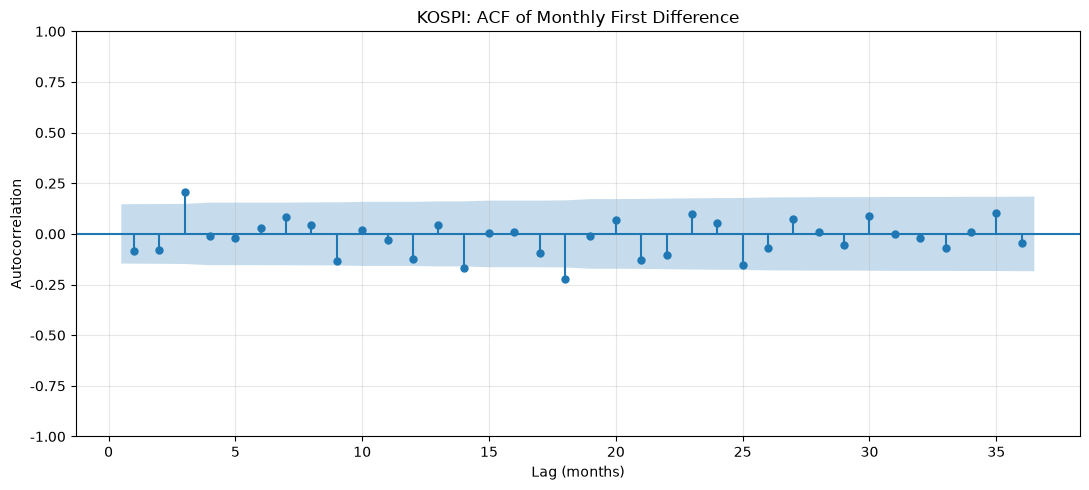

[SAVED] KOSPI: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\figures\stationarity_acf_first_difference_kospi.png


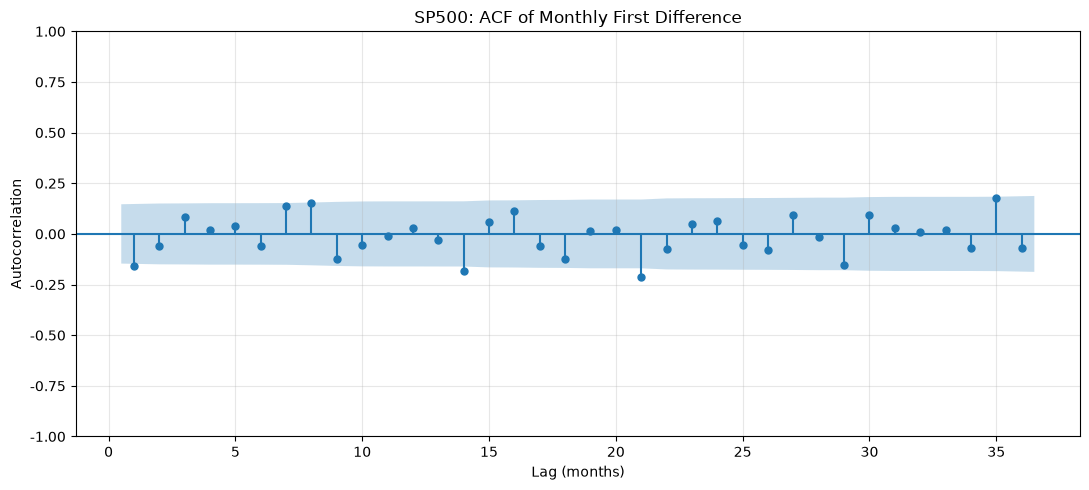

[SAVED] SP500: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\figures\stationarity_acf_first_difference_sp500.png


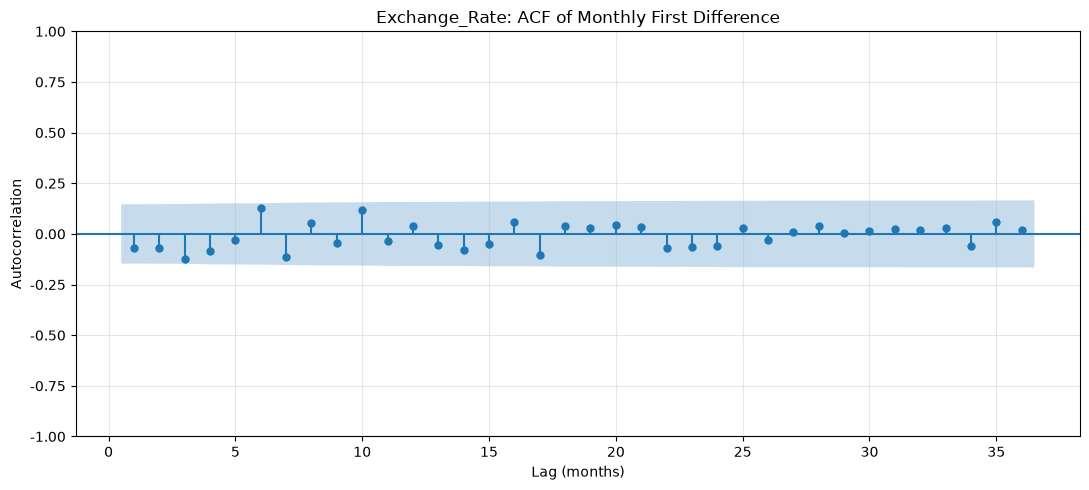

[SAVED] Exchange_Rate: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\figures\stationarity_acf_first_difference_exchange_rate.png


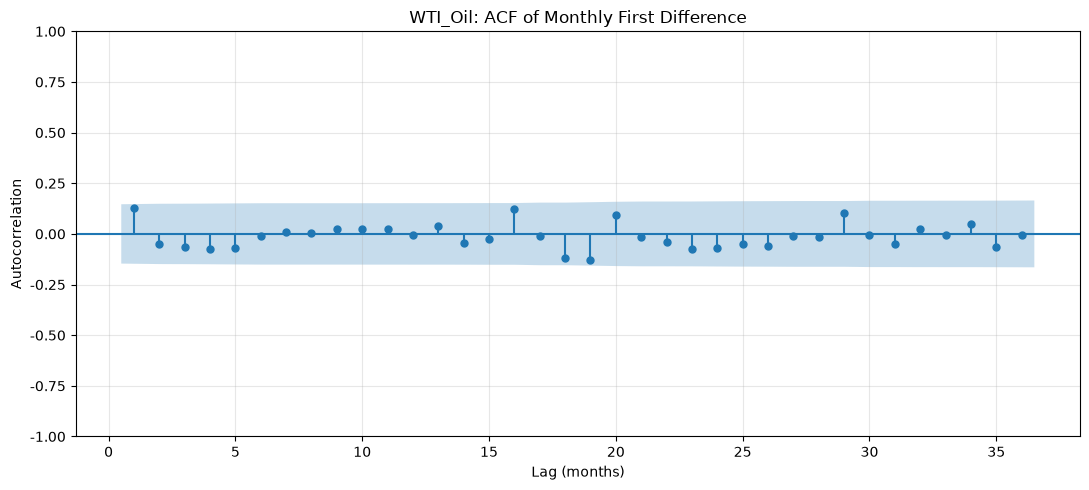

[SAVED] WTI_Oil: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\figures\stationarity_acf_first_difference_wti_oil.png


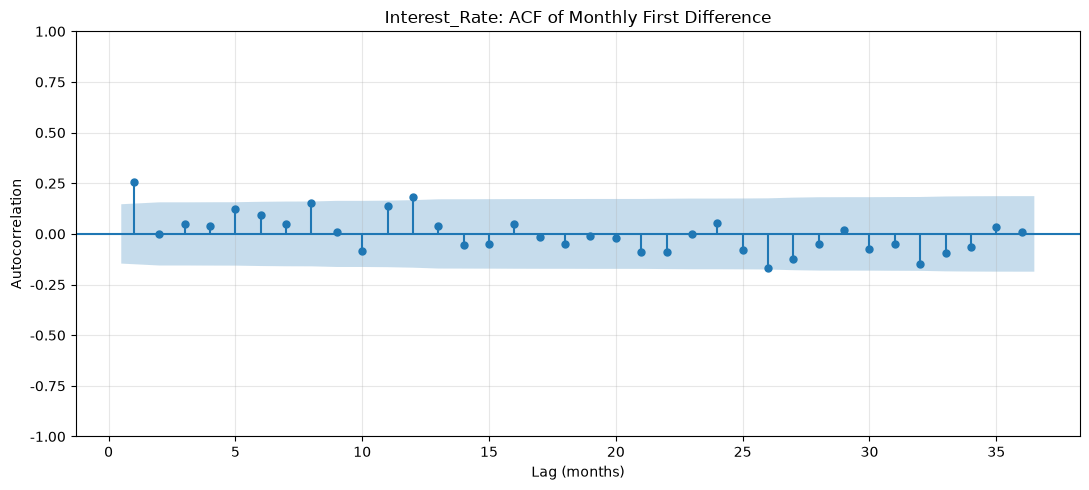

[SAVED] Interest_Rate: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\figures\stationarity_acf_first_difference_interest_rate.png


In [13]:
acf_diff_figure_paths = {}

acf_lags = 36

for variable in df_diff.columns:
    figure_path = (
        fig_dir
        / (
            "stationarity_acf_first_difference_"
            f"{variable.lower()}.png"
        )
    )

    fig, ax = plt.subplots(figsize=(11, 5))

    plot_acf(
        df_diff[variable],
        lags=acf_lags,
        alpha=0.05,
        zero=False,
        ax=ax,
    )

    ax.set_title(
        f"{variable}: ACF of Monthly First Difference"
    )

    ax.set_xlabel("Lag (months)")
    ax.set_ylabel("Autocorrelation")

    ax.grid(
        True,
        alpha=0.3,
    )

    fig.tight_layout()

    fig.savefig(
        figure_path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    acf_diff_figure_paths[variable] = figure_path

    print(
        f"[SAVED] {variable}: {figure_path}"
    )

## 9. 정상성 진단 최종 결론

수준 시계열에 대한 ADF·KPSS 검정 결과 KOSPI, S&P 500, 원/달러 환율 및 국고채 3년 금리는 비정상으로 판단되었다. WTI는 ADF와 KPSS가 모두 귀무가설을 기각하지 못해 정상 또는 비정상으로 명확히 분류할 수 없는 불확정 결과를 보였다.

반면 5개 변수 모두 1차 차분 후 ADF 검정에서는 단위근 귀무가설이 기각되었고, KPSS 검정에서는 정상성 귀무가설이 기각되지 않았다. 이에 따라 1차 차분 시계열은 모두 정상으로 판단하였다.

후속 회귀분석에서는 수준 OLS와 1차 차분 OLS를 다음과 같이 구분한다.

1. 수준 OLS는 비정상 시계열을 그대로 사용했을 때 나타날 수 있는 높은 설명력, 유의한 계수 및 잔차 자기상관을 진단하는 비교 모형으로 사용한다.
2. 1차 차분 OLS는 정상성이 확인된 월간 변화량 사이의 단기 관계를 추정하는 주 분석 모형으로 사용한다.
3. 수준 모형과 차분 모형은 종속변수의 척도와 경제적 의미가 다르므로 결정계수를 직접 비교하여 우열을 판단하지 않는다.
4. 수준 변수 사이의 장기 관계를 주장하려면 별도의 공적분 검정이 필요하므로, 본 분석에서는 수준 회귀계수를 장기 균형관계로 해석하지 않는다.


In [14]:
def format_adf_pvalue(value: float) -> str:
    """매우 작은 ADF p-value를 반올림된 0과 구분한다."""
    if value < 0.000001:
        return "< 0.000001"

    return f"{value:.6f}"


def format_kpss_pvalue(
    value: float,
    warning_message: str,
) -> str:
    """KPSS 통계표의 p-value 상·하한을 명확히 표현한다."""
    warning_exists = bool(
        str(warning_message).strip()
    )

    if warning_exists and np.isclose(value, 0.10):
        return "≥ 0.10"

    if warning_exists and np.isclose(value, 0.01):
        return "≤ 0.01"

    return f"{value:.6f}"


def korean_decision(decision: str) -> str:
    mapping = {
        "Stationary": "정상",
        "Non-stationary": "비정상",
        "Conflicting": "상충",
        "Inconclusive": "불확정",
    }

    return mapping.get(
        decision,
        decision,
    )


report_table_rows = []

for variable in df_level.columns:
    level_row = level_stationarity_results.loc[
        variable
    ]

    diff_row = diff_stationarity_results.loc[
        variable
    ]

    report_table_rows.append(
        "| "
        f"{variable} | "
        f"{format_adf_pvalue(level_row['adf_pvalue'])} | "
        f"{format_kpss_pvalue(level_row['kpss_pvalue'], level_row['kpss_warning'])} | "
        f"{korean_decision(level_row['combined_decision'])} | "
        f"{format_adf_pvalue(diff_row['adf_pvalue'])} | "
        f"{format_kpss_pvalue(diff_row['kpss_pvalue'], diff_row['kpss_warning'])} | "
        f"{korean_decision(diff_row['combined_decision'])} | "
        "1차 차분 |"
    )


level_decision_counts = (
    level_stationarity_results[
        "combined_decision"
    ]
    .value_counts()
    .to_dict()
)

diff_stationary_count = int(
    (
        diff_stationarity_results[
            "combined_decision"
        ]
        == "Stationary"
    ).sum()
)


stationarity_report_lines = [
    "# 금융 시계열 정상성 진단 결과",
    "",
    f"- 실행 시각: {RUN_TIMESTAMP:%Y-%m-%d %H:%M:%S} KST",
    f"- 분석 기간: {df_level.index.min():%Y-%m} ~ {df_level.index.max():%Y-%m}",
    f"- 수준 표본 수: {len(df_level)}개월",
    f"- 1차 차분 표본 수: {len(df_diff)}개월",
    f"- 유의수준: {SIGNIFICANCE_LEVEL:.0%}",
    "",
    "## 1. 변수별 검정 결과",
    "",
    (
        "| 변수 | 수준 ADF p-value | 수준 KPSS p-value | "
        "수준 판단 | 차분 ADF p-value | 차분 KPSS p-value | "
        "차분 판단 | 권고 변환 |"
    ),
    (
        "|---|---:|---:|---|---:|---:|---|---|"
    ),
    *report_table_rows,
    "",
    "## 2. 종합 결과",
    "",
    (
        f"- 수준 시계열: 비정상 "
        f"{level_decision_counts.get('Non-stationary', 0)}개, "
        f"불확정 "
        f"{level_decision_counts.get('Inconclusive', 0)}개, "
        f"정상 "
        f"{level_decision_counts.get('Stationary', 0)}개"
    ),
    (
        f"- 1차 차분 시계열: "
        f"{diff_stationary_count}/{len(df_diff.columns)}개 정상"
    ),
    (
        "- KOSPI, S&P 500, 원/달러 환율 및 국고채 3년 금리는 "
        "수준에서 정상성이 확보되지 않았다."
    ),
    (
        "- WTI는 수준 ADF와 KPSS 결과가 모두 귀무가설을 "
        "기각하지 못해 불확정으로 분류되었다."
    ),
    (
        "- 모든 변수는 1차 차분 후 ADF와 KPSS에서 "
        "정상으로 판단되었다."
    ),
    "",
    "## 3. 모델링 결정",
    "",
    (
        "- 수준 OLS는 비정상 시계열 회귀의 허위회귀 위험을 "
        "진단하는 비교 모형으로 사용한다."
    ),
    (
        "- 1차 차분 OLS는 월간 변화량 간 단기 관계를 "
        "추정하는 주 분석 모형으로 사용한다."
    ),
    (
        "- 수준 모형과 차분 모형은 종속변수와 척도가 다르므로 "
        "R²를 직접 비교하여 성능 우열을 판단하지 않는다."
    ),
    (
        "- 수준 변수 사이의 장기 균형관계를 주장하려면 "
        "별도의 공적분 검정이 필요하다."
    ),
    "",
    "## 4. p-value 해석 주의사항",
    "",
    (
        "- 화면에 0.000000으로 표시된 ADF p-value는 "
        "정확히 0이 아니라 매우 작은 값이다."
    ),
    (
        "- KPSS p-value가 0.10으로 표시된 경우 실제 값은 "
        "통계표 상한인 0.10 이상일 수 있다."
    ),
    (
        "- KPSS p-value가 0.01로 표시된 경우 실제 값은 "
        "통계표 하한인 0.01 이하일 수 있다."
    ),
]


stationarity_report_path = (
    report_dir / "stationarity_findings.md"
)

stationarity_report_path.write_text(
    "\n".join(stationarity_report_lines),
    encoding="utf-8",
)


print("[STATIONARITY SUMMARY]")
print(
    f"Level decisions: "
    f"{level_decision_counts}"
)
print(
    f"Stationary after first difference: "
    f"{diff_stationary_count}/"
    f"{len(df_diff.columns)}"
)

print(
    f"\n[SAVED] Stationarity findings report: "
    f"{stationarity_report_path}"
)

print("\n[REPORT PREVIEW]\n")

print(
    "\n".join(
        stationarity_report_lines[:25]
    )
)

[STATIONARITY SUMMARY]
Level decisions: {'Non-stationary': 4, 'Inconclusive': 1}
Stationary after first difference: 5/5

[SAVED] Stationarity findings report: c:\Users\user\Desktop\주진호\05.ICT 인턴십\01.KOSPI\outputs\reports\stationarity_findings.md

[REPORT PREVIEW]

# 금융 시계열 정상성 진단 결과

- 실행 시각: 2026-06-27 06:40:42 KST
- 분석 기간: 2010-01 ~ 2024-12
- 수준 표본 수: 180개월
- 1차 차분 표본 수: 179개월
- 유의수준: 5%

## 1. 변수별 검정 결과

| 변수 | 수준 ADF p-value | 수준 KPSS p-value | 수준 판단 | 차분 ADF p-value | 차분 KPSS p-value | 차분 판단 | 권고 변환 |
|---|---:|---:|---|---:|---:|---|---|
| KOSPI | 0.182365 | ≤ 0.01 | 비정상 | < 0.000001 | ≥ 0.10 | 정상 | 1차 차분 |
| SP500 | 0.998091 | ≤ 0.01 | 비정상 | < 0.000001 | ≥ 0.10 | 정상 | 1차 차분 |
| Exchange_Rate | 0.650256 | ≤ 0.01 | 비정상 | < 0.000001 | ≥ 0.10 | 정상 | 1차 차분 |
| WTI_Oil | 0.162278 | 0.056736 | 불확정 | < 0.000001 | ≥ 0.10 | 정상 | 1차 차분 |
| Interest_Rate | 0.054152 | 0.048925 | 비정상 | < 0.000001 | ≥ 0.10 | 정상 | 1차 차분 |

## 2. 종합 결과

- 수준 시계열: 비정상 4개, 불확정 1개, 정상 0개
- 1차 차분 시계열: 5/5개 정상
- KOSP